# Titanic Dataset: Exploratory Data Analysis

## Data Understanding

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# importing dataset and previewing first 5 rows
df = pd.read_csv('cleaned_titanic.csv')
df.head()

,Passenger_ID,Survived,Ticket_Class,Name,Sex,Age,Siblings_and_Spouses,Parents_and_Children,Ticket,Fare,Port_of_Embarkation
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.25,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.28,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.92,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.10,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.05,S


In [2]:
# previewing last 5 rows
df.tail()

,Passenger_ID,Survived,Ticket_Class,Name,Sex,Age,Siblings_and_Spouses,Parents_and_Children,Ticket,Fare,Port_of_Embarkation
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.00,S
887,888,1,1,"Graham, Miss. Margaret Edith",Female,19.0,0,0,112053,30.00,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Female,28.0,1,2,W./C. 6607,23.45,S
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.00,C
890,891,0,3,"Dooley, Mr. Patrick",Male,32.0,0,0,370376,7.75,Q


In [3]:
# checking shape (rows and columns)
df.shape

(891, 11)

In [4]:
# checking column names
df.columns

Index(['Passenger_ID', 'Survived', 'Ticket_Class', 'Name', 'Sex', 'Age',
       'Siblings_and_Spouses', 'Parents_and_Children', 'Ticket', 'Fare',
       'Port_of_Embarkation'],
      dtype='str')

In [5]:
# checking data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Passenger_ID          891 non-null    int64  
 1   Survived              891 non-null    int64  
 2   Ticket_Class          891 non-null    int64  
 3   Name                  891 non-null    str    
 4   Sex                   891 non-null    str    
 5   Age                   891 non-null    float64
 6   Siblings_and_Spouses  891 non-null    int64  
 7   Parents_and_Children  891 non-null    int64  
 8   Ticket                891 non-null    str    
 9   Fare                  891 non-null    float64
 10  Port_of_Embarkation   891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [6]:
# checking summary statistics
df.describe()

,Passenger_ID,Survived,Ticket_Class,Age,Siblings_and_Spouses,Parents_and_Children,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204366
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693414
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.450000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.330000


In [7]:
# checking for missing values
df.isnull().sum()

Passenger_ID            0
Survived                0
Ticket_Class            0
Name                    0
Sex                     0
Age                     0
Siblings_and_Spouses    0
Parents_and_Children    0
Ticket                  0
Fare                    0
Port_of_Embarkation     0
dtype: int64

In [8]:
# checking for duplicate rows
df.duplicated().sum()

np.int64(0)

##### Description
This dataset holds the data of the passengers aboard the RMS Titanic in April, 1912. It contains a total of 891 rows and 11 columns containing their personal information, their tickets and destination, the number of family members they had, and whether they survived or not. The features are a mix of numerical columns (Age, Fare, Siblings_and_Spouses, Parents_and_Children), categorical columns (Sex, Ticket_Class, Port_of_Embarkation), and identifier/text columns (Passenger_ID, Name, Ticket). The target column, Survived, is binary (0 = did not survive, 1 = survived). Since this is the cleaned dataset from Project 1, there are no missing values or duplicate rows to handle. Overall, the dataset gives a solid mix of demographic and travel-related information that can be used to explore which factors (such as gender, class, age, and fare) were associated with a higher chance of survival.

## Feature Engineering

##### Family Size

Family_Size was created by adding Siblings_and_Spouses and Parents_and_Children together (plus the passenger themselves). The original data split family members into two separate columns, which makes it hard to see a passenger's total family size at a glance. Combining them into one number makes it much easier to analyze whether travelling with a small, large, or no family at all affected survival.

In [9]:
# creating column to check family size
df["Family_Size"] = df["Siblings_and_Spouses"] + df["Parents_and_Children"] + 1
df

,Passenger_ID,Survived,Ticket_Class,Name,Sex,Age,Siblings_and_Spouses,Parents_and_Children,Ticket,Fare,Port_of_Embarkation,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.25,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.28,C,2
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.92,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.10,S,2
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.05,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.00,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",Female,19.0,0,0,112053,30.00,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Female,28.0,1,2,W./C. 6607,23.45,S,4
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.00,C,1


##### Is Alone

The Is Alone column checks whether a passenger was travelling alone by checking for a family size of 1. It allows comparison of survival rates between passengers travelling alone and passengers travelling with family, to check if it influences survival.

In [10]:
# creating column to check if the passenger was travelling alone
df["Is_Alone"] = np.where(
    df["Family_Size"] == 1,
    "Yes",
    "No"
)
df

,Passenger_ID,Survived,Ticket_Class,Name,Sex,Age,Siblings_and_Spouses,Parents_and_Children,Ticket,Fare,Port_of_Embarkation,Family_Size,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.25,S,2,No
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.28,C,2,No
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.92,S,1,Yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.10,S,2,No
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.05,S,1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.00,S,1,Yes
887,888,1,1,"Graham, Miss. Margaret Edith",Female,19.0,0,0,112053,30.00,S,1,Yes
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Female,28.0,1,2,W./C. 6607,23.45,S,4,No
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.00,C,1,Yes


##### Age Group

Age Group was created to convert the continuous Age variable into meaningful age categories. It allows comparison of survival patterns between children, teenagers, adults and senior citizens. This helps us identify whether certain age groups were prioritized or more vulnerable during the disaster.

In [11]:
# creating column to group passengers by age
df["Age_Group"] = pd.cut(
    df["Age"],
    bins = [0, 12, 19, 59, float('inf')],
    labels = ["Child", "Teenager", "Adult", "Senior Citizen"],
    include_lowest = True
)
df

,Passenger_ID,Survived,Ticket_Class,Name,Sex,Age,Siblings_and_Spouses,Parents_and_Children,Ticket,Fare,Port_of_Embarkation,Family_Size,Is_Alone,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.25,S,2,No,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.28,C,2,No,Adult
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.92,S,1,Yes,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.10,S,2,No,Adult
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.05,S,1,Yes,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.00,S,1,Yes,Adult
887,888,1,1,"Graham, Miss. Margaret Edith",Female,19.0,0,0,112053,30.00,S,1,Yes,Teenager
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Female,28.0,1,2,W./C. 6607,23.45,S,4,No,Adult
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.00,C,1,Yes,Adult


##### Fare Category

Fare Category divides passengers into low, medium, and high fare categories. This makes it easier to examine whether passengers paying higher fares had greater chances of survival. The ranges were selected to provide simple and interpretable fare groups for comparison.

In [12]:
# creating column to check fare price category
df["Fare_Category"] = pd.cut(
    df["Fare"],
    bins = [0, 25, 75, float('inf')],
    labels=["Low", "Medium", "High"],
    include_lowest=True
    )
df

,Passenger_ID,Survived,Ticket_Class,Name,Sex,Age,Siblings_and_Spouses,Parents_and_Children,Ticket,Fare,Port_of_Embarkation,Family_Size,Is_Alone,Age_Group,Fare_Category
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.25,S,2,No,Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.28,C,2,No,Adult,Medium
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.92,S,1,Yes,Adult,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.10,S,2,No,Adult,Medium
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.05,S,1,Yes,Adult,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.0,0,0,211536,13.00,S,1,Yes,Adult,Low
887,888,1,1,"Graham, Miss. Margaret Edith",Female,19.0,0,0,112053,30.00,S,1,Yes,Teenager,Medium
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Female,28.0,1,2,W./C. 6607,23.45,S,4,No,Adult,Low
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.0,0,0,111369,30.00,C,1,Yes,Adult,Medium


## Exploratory Data Analysis

##### Q1. What percentage of passengers survived? Create an appropriate chart. Write your observation.

In [13]:
survival_percentage = df["Survived"].mean() * 100
print(f"Survival Rate: {survival_percentage:.2f}%")

Survival Rate: 38.38%


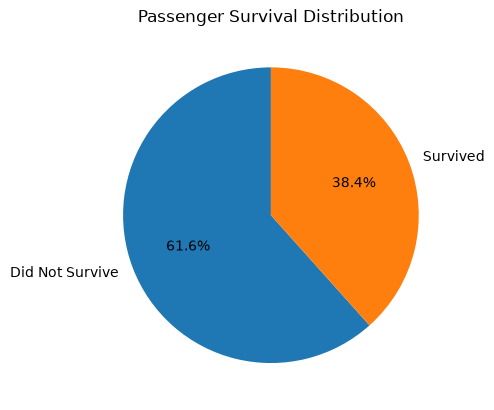

In [14]:
survival_counts = df["Survived"].value_counts()
plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Passenger Survival Distribution")
plt.show()

**Observation:** Only 38.38% of passengers survived, while the majority (61.62%) did not. This shows that survival was not the outcome for most passengers.

##### Q2. Which gender had the highest survival rate? Create a visualization. Explain your findings.

In [15]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100
print(gender_survival)

Sex
Female    74.203822
Male      18.890815
Name: Survived, dtype: float64


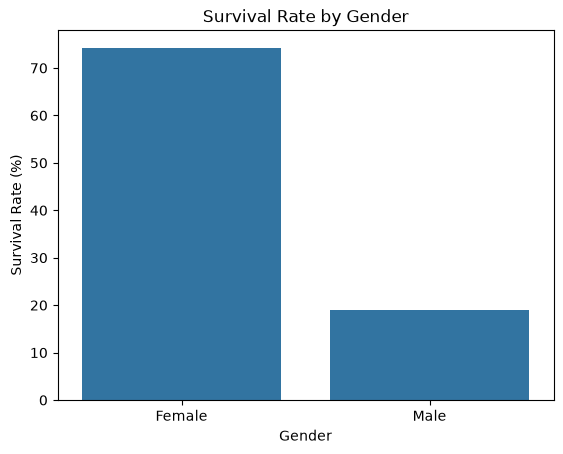

In [ ]:
sns.barplot(
    x=gender_survival.index,
    y=gender_survival.values
)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.show()

**Observation:** Females had a dramatically higher survival rate (74.20%) than males (18.89%). This shows a strong difference in survival rates between male and female passengers.

##### Q3. Which passenger class had the highest survival rate? Support your answer with a chart.

In [17]:
class_survival = (
    df.groupby("Ticket_Class")["Survived"]
    .mean()
    .mul(100)
)
print(class_survival)

Ticket_Class
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


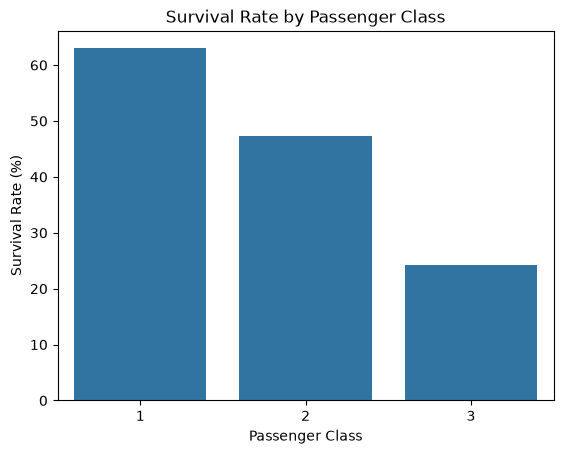

In [18]:
sns.barplot(
    x=class_survival.index,
    y=class_survival.values
)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.show()

**Observation:** First class passengers had the highest survival rate (62.96%), followed by second class (47.28%), while third class passengers had the lowest by far (24.24%). This shows a clear difference in survival rates across passenger classes.

##### Q4. Does age affect survival? Use an appropriate visualization. Explain your conclusion.

In [19]:
agegroup_survival = (
    df.groupby("Age_Group", observed=True)["Survived"]
    .mean()
    .mul(100)
)
print(agegroup_survival)

Age_Group
Child             57.971014
Teenager          41.052632
Adult             36.519258
Senior Citizen    26.923077
Name: Survived, dtype: float64


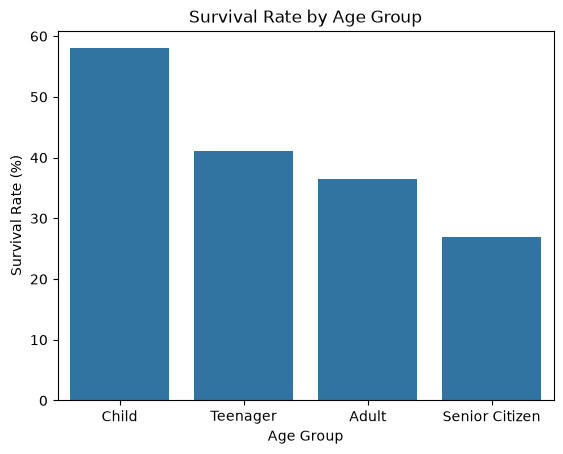

In [20]:
sns.barplot(
    x=agegroup_survival.index,
    y=agegroup_survival.values
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

plt.show()

**Observation:** Children had the highest survival rate (57.97%), followed by Teenagers (41.05%), Adults (36.52%), and Senior Citizens had the lowest (26.92%). This suggests that age was associated with survival, with younger passengers generally having higher survival rates.

##### Q5. Does fare influence survival? Support your answer with visualization.

In [21]:
fare_survival = (
    df.groupby("Fare_Category", observed=True)["Survived"]
    .mean()
    .mul(100)
)
print(fare_survival)

Fare_Category
Low       28.725314
Medium    45.569620
High      76.288660
Name: Survived, dtype: float64


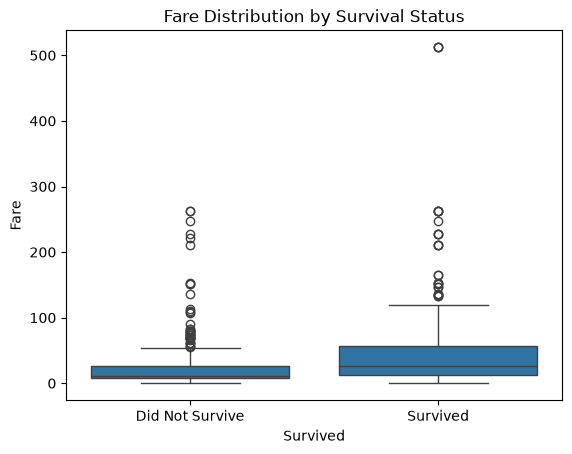

In [22]:
sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)
plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.show()

**Observation:** Higher fares were associated with higher survival rates. Passengers in the "High" fare category survived at 76.29%, compared to 45.57% for "Medium" fare and only 28.73% for "Low" fare. This relationship may partly reflect the relationship between fare and passenger class, since first-class passengers generally paid higher fares.

##### Q6. Did passengers travelling alone survive more often? Use a visualization. Explain your observation.

In [23]:
alone_survival = (
    df.groupby("Is_Alone")["Survived"]
    .mean()
    .mul(100)
)
print(alone_survival)

Is_Alone
No     50.564972
Yes    30.353818
Name: Survived, dtype: float64


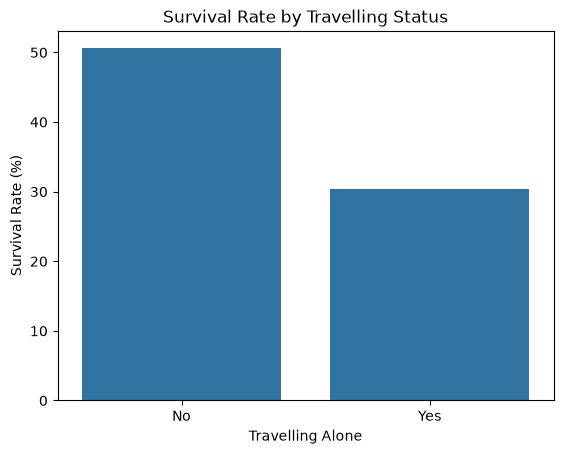

In [24]:
sns.barplot(
    x=alone_survival.index,
    y=alone_survival.values
)
plt.title("Survival Rate by Travelling Status")
plt.xlabel("Travelling Alone")
plt.ylabel("Survival Rate (%)")
plt.show()

**Observation:** Passengers travelling with family had a higher survival rate (50.56%) than those travelling alone (30.35%), showing an association between travelling status and survival.

##### Q7. Which embarkation port had the highest survival rate? Create a chart and explain the result.

In [25]:
embarked_survival = (
    df.groupby("Port_of_Embarkation")["Survived"]
    .mean()
    .mul(100)
)
print(embarked_survival)

Port_of_Embarkation
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


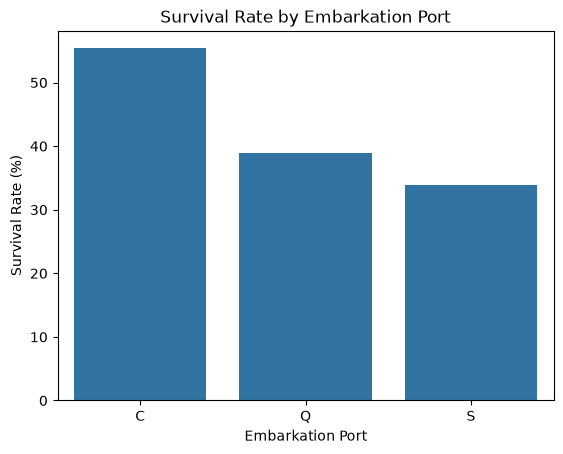

In [26]:
sns.barplot(
    x=embarked_survival.index,
    y=embarked_survival.values
)
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")
plt.show()

**Observation:** Passengers who boarded at Cherbourg (C) had the highest survival rate (55.36%), followed by Queenstown (Q) at 38.96%, while Southampton (S) had the lowest at 33.90%. This is likely connected to class distribution, since a larger proportion of Cherbourg passengers travelled in first class.

##### Q8. What is the relationship between passenger class and fare? Support your answer using an appropriate visualization.

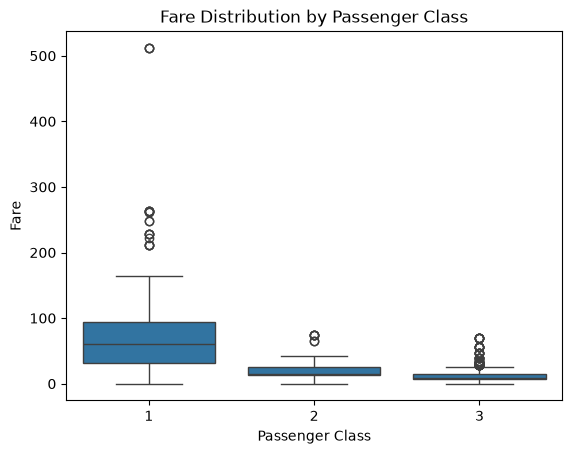

In [27]:
sns.boxplot(
    data=df,
    x="Ticket_Class",
    y="Fare"
)
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

**Observation:** There is a strong relationship between passenger class and fare. First class passengers paid noticeably higher fares (with several high outliers), followed by second class, with third class fares being the lowest and most tightly clustered.

##### Q9. Create a Correlation Heatmap. Explain: strongest positive correlation, strongest negative correlation, and any interesting observations.

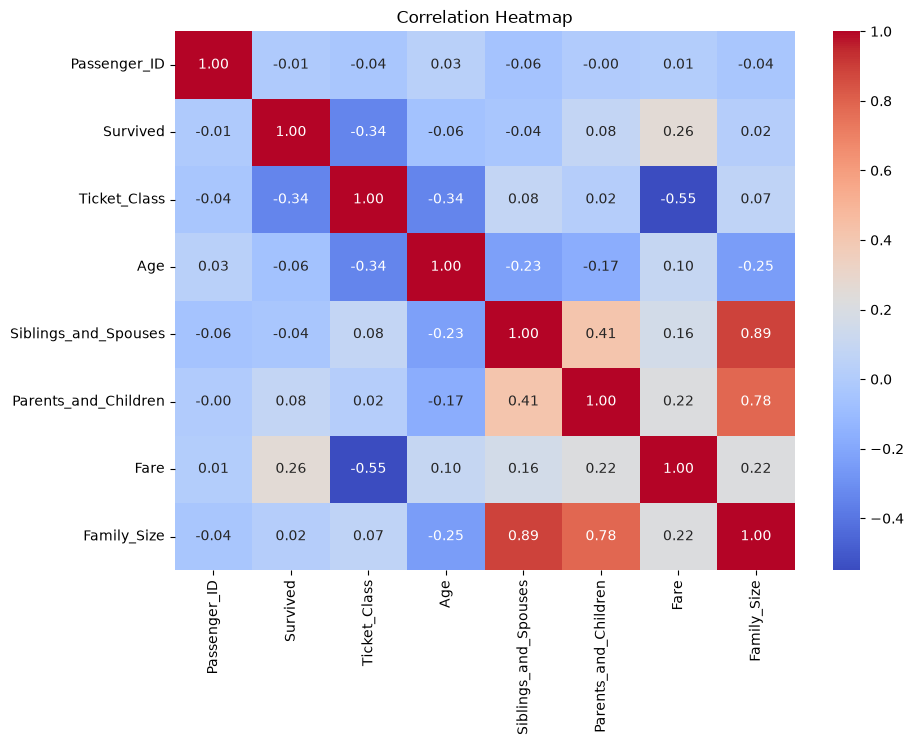

In [28]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

**Explanation:** The strongest positive correlation with Survived is Fare (+0.26), meaning passengers who paid more tended to survive more often. The strongest negative correlation with Survived is Ticket_Class (-0.34), meaning passengers in a lower class tended to survive less often. There is also a very strong positive correlation between Siblings_and_Spouses and Family_Size (+0.89) and between Parents_and_Children and Family_Size (+0.78), which is expected since Family_Size is built from those two columns. There is also a fairly strong negative correlation between Ticket_Class and Fare (-0.55), reinforcing that higher class paid higher fares.

##### Q10. Create one additional analysis of your own (e.g. Family Size vs Survival, Age Group vs Passenger Class, Fare Category vs Survival, Family Size vs Fare, Age Group vs Gender). Explain your findings.

In [29]:
family_survival = (
    df.groupby("Family_Size")["Survived"]
    .mean()
    .mul(100)
)
print(family_survival)

Family_Size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


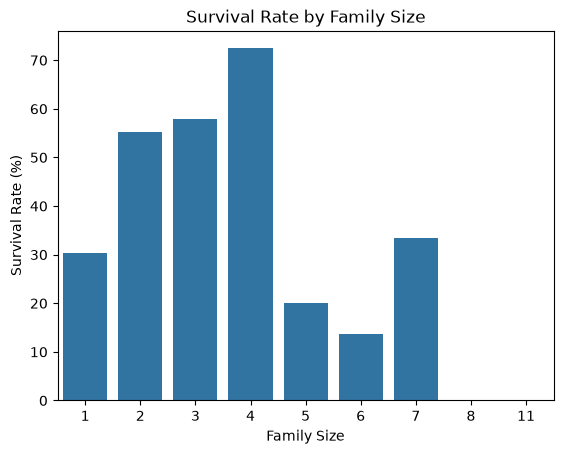

In [30]:
sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.show()

**Finding:** Survival rate rises with family size up to a point, then drops off. Passengers with a family size of 2 to 4 had the highest survival rates (55–72%), while solo travellers (family size 1) survived at only 30.35%, and passengers in very large families (5 or more) survived at much lower rates, some as low as 0%. This shows that survival rates varied by family size, with passengers in smaller families generally having higher survival rates than solo travellers and those in very large families.

## Statistical Analysis

In [31]:
numerical_columns = ["Age", "Fare", "Family_Size"]
summary_statistics = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Standard Deviation": df[numerical_columns].std()
})
summary_statistics

,Mean,Median,Mode,Standard Deviation
Age,29.361582,28.00,28.00,13.019697
Fare,32.204366,14.45,8.05,49.693414
Family_Size,1.904602,1.00,1.00,1.613459


**Age:** The mean (29.36) is close to the median and mode (both 28), showing only a slight right skew from a smaller number of older passengers. The standard deviation (13.02) shows a fairly wide spread of ages aboard.

**Fare:** The mean (32.20) is much higher than the median (14.45) and mode (8.05), showing a strong right skew. Most passengers paid relatively low fares, while a small number of first class passengers paid very high fares that pull the average up. The large standard deviation (49.69) confirms this wide spread.

**Family_Size:** The mean (1.90) is close to the median and mode (both 1), showing that most passengers travelled alone or with only one other family member, while a smaller number of large families pull the mean slightly higher. The standard deviation (1.61) is relatively small, showing family size doesn't vary as wildly as fare.

## Dashboard

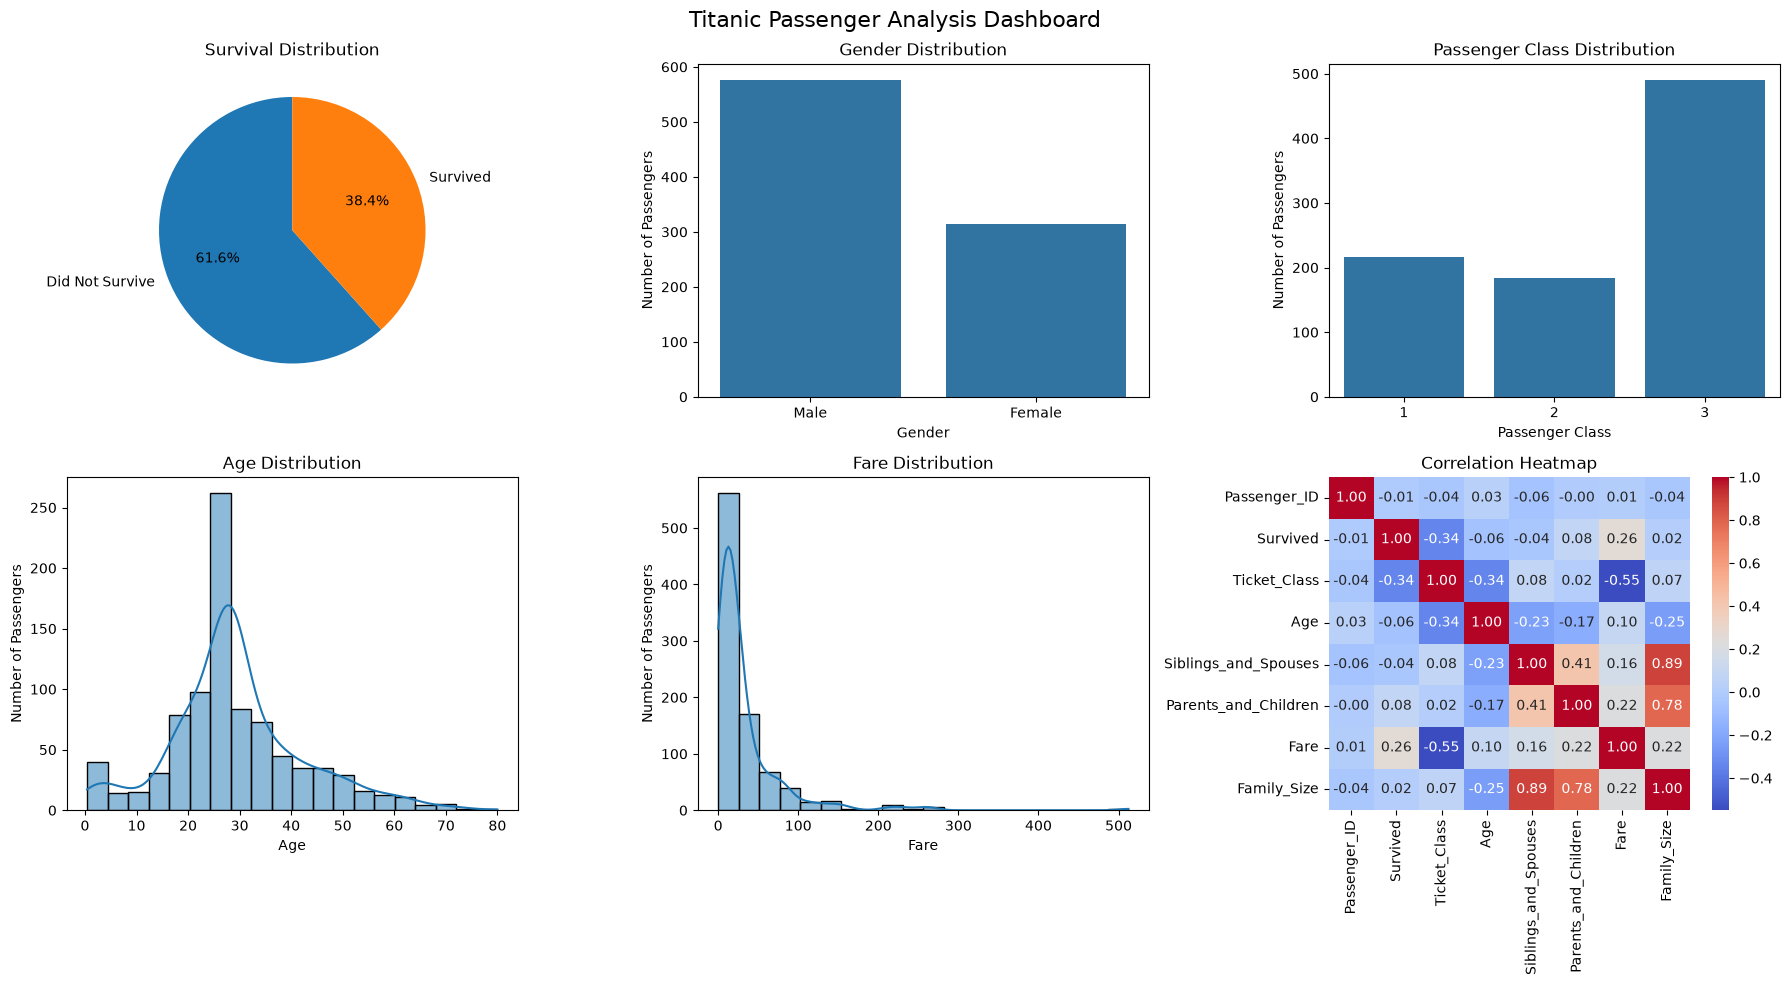

In [32]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)
survival_counts = df["Survived"].value_counts()

axes[0, 0].pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)
axes[0, 0].set_title("Survival Distribution")

sns.countplot(
    data=df,
    x="Sex",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Gender Distribution")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Number of Passengers")

sns.countplot(
    data=df,
    x="Ticket_Class",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Passenger Class Distribution")
axes[0, 2].set_xlabel("Passenger Class")
axes[0, 2].set_ylabel("Number of Passengers")

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Age Distribution")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Number of Passengers")

sns.histplot(
    data=df,
    x="Fare",
    bins=20,
    kde=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Fare Distribution")
axes[1, 1].set_xlabel("Fare")
axes[1, 1].set_ylabel("Number of Passengers")

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Correlation Heatmap")

fig.suptitle("Titanic Passenger Analysis Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

## Business Insights

1. Most passengers did not survive. Only 38.38% of passengers survived, while 61.62% did not.

2. Female passengers had a much higher survival rate than males. Their survival rates were 74.20% and 18.89%, respectively.

3. Survival was higher among first-class passengers. First-class passengers had a 62.96% survival rate, compared with 24.24% for third-class passengers.

4. Younger passengers generally had higher survival rates. Children had the highest survival rate at 57.97%, while senior citizens had the lowest at 26.92%.

5. Higher-fare passengers had higher survival rates. High-fare passengers had a 76.29% survival rate, compared with 28.73% for low-fare passengers.

6. Passengers travelling with family had higher survival rates. Their survival rate was 50.56%, compared with 30.35% for passengers travelling alone.

7. Survival rates differed by embarkation port. Passengers from Cherbourg had the highest survival rate at 55.36%, while Southampton had the lowest at 33.90%.

8. Passenger class and fare were strongly related. Higher-class passengers generally paid higher fares, showing a clear relationship between the two variables.

9. Family size was related to survival. Passengers in smaller families generally had higher survival rates, while very large families had lower survival rates.

10. Fare and passenger class showed the strongest relationships with survival. Fare had a positive correlation with survival (+0.26), while passenger class had a negative correlation (-0.34).

## Business Recommendations

1. **Improve emergency access for third-class passengers.** Since third-class passengers had the lowest survival rate, their evacuation routes and access to lifeboats should be improved.

2. **Provide clear evacuation support for vulnerable passengers.** Emergency procedures should ensure that passengers who need additional assistance can evacuate safely.

3. **Provide more support for families during emergencies.** Since passengers travelling with family had higher survival rates, staff should help families stay together during evacuations.

4. **Provide equal safety resources across all passenger classes.** Since survival differed greatly by passenger class and fare, safety equipment and evacuation access should be available equally to all passengers.

5. **Provide extra assistance to passengers travelling alone.** Since solo passengers had a lower survival rate, staff could give them additional guidance and support during emergencies.
